In [1]:
# imports met nodige libraries
import pandas as pd # voor tabellen
import numpy as np  # voor rekenen met tabellen

from sklearn.model_selection import train_test_split # data opdelen in train en test
from sklearn.compose import ColumnTransformer # numerieke/categorische kolommen andere behandeling
from sklearn.pipeline import Pipeline # preprocessing en model in 1 stroom zetten
from sklearn.preprocessing import OneHotEncoder, StandardScaler # tekstkolommen naar 0 en 1
from sklearn.impute import SimpleImputer # schaalt numerieke kolommen
from sklearn.linear_model import SGDRegressor # vult missende waarden 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # voor model beoordeling

pd.set_option("display.max_columns", None) # alle kolommen van dataframe word laten zien wnr gevraagd 


In [2]:
# leest beide tabjes uit excel in als DataFrames
bestand = "AmesHousing.xlsx"

df = pd.read_excel(bestand, sheet_name="AmesHousing") # ameshousing data
data_dictionary = pd.read_excel(bestand, sheet_name="Data Dictionary") # uitleg kolommen

print("Vorm van de dataset:", df.shape) # controleren hvl rijen + kolommen
display(df.head()) #eerste rijen controleren
display(data_dictionary) # kijk hieronder 


Vorm van de dataset: (2930, 12)


,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,1Story
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,1Story
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,1Story
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,1Story
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,2Story


,Variabele,Betekenis
0,ID,"Uniek nummer per huis, te vergelijken met een ..."
1,SalePrice,Verkoopprijs van het huis (in dollars: USD)
2,Garage,Geeft weer of het huis wel/geen garage bevat
3,Overall Qual,Algemene kwaliteit van materialen en afwerking...
4,Gr Liv Area,Woonoppervlak boven de grond (square feet)
5,Total Bsmt SF,Totale oppervlakte van de kelder
6,Lot Area,Grootte van het perceel (square feet)
7,Year Built,Bouwjaar van het huis
8,Full Bath,Aantal volledige badkamers
9,Bedroom AbvGr,Aantal slaapkamers boven de grond


In [3]:
# checken of elke kolom van excel goed is ingelezen
print("Kolommen in de DataFrame:")
print(df.columns.tolist())


Kolommen in de DataFrame:
['ID', 'SalePrice', 'Garage', 'Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Lot Area', 'Year Built', 'Full Bath', 'Bedroom AbvGr', 'Neighborhood', 'House Style']


In [4]:
#  welke hyperparameters heeft model nodig
help(SGDRegressor)


Help on class SGDRegressor in module sklearn.linear_model._stochastic_gradient:

class SGDRegressor(BaseSGDRegressor)
 |  SGDRegressor(
 |      loss='squared_error',
 |      *,
 |      penalty='l2',
 |      alpha=0.0001,
 |      l1_ratio=0.15,
 |      fit_intercept=True,
 |      max_iter=1000,
 |      tol=0.001,
 |      shuffle=True,
 |      verbose=0,
 |      epsilon=0.1,
 |      random_state=None,
 |      learning_rate='invscaling',
 |      eta0=0.01,
 |      power_t=0.25,
 |      early_stopping=False,
 |      validation_fraction=0.1,
 |      n_iter_no_change=5,
 |      warm_start=False,
 |      average=False
 |  )
 |
 |  Linear model fitted by minimizing a regularized empirical loss with SGD.
 |
 |  SGD stands for Stochastic Gradient Descent: the gradient of the loss is
 |  estimated each sample at a time and the model is updated along the way with
 |  a decreasing strength schedule (aka learning rate).
 |
 |  The regularizer is a penalty added to the loss function that shrinks mode

In [5]:
# Dit blok kiest de eerste features en splitst de data verticaal in X en y
gekozen_features = ["Overall Qual", "Gr Liv Area", "Neighborhood"]
target = "SalePrice"

X = df[gekozen_features]   # gekozen invoerfeatures (X ipv x want meerdere kolommen matrix), onafhankelijke variabelen
y = df[target]  # targetvariabele (afhankelijke variabele) die we willen voorspellen

print("Vorm van X:", X.shape) # hvl rijen en kolommen in totaal. eerste getal = rijen tweede = kolommen
print("Vorm van y:", y.shape) # zelfde als hierboven sukkel


Vorm van X: (2930, 3)
Vorm van y: (2930,)


In [6]:
# splitst de data horizontaal in train en test
# X_train, X_test, y_train en y_test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42  # 20% van data voor testen rest voor trainen. 
    # random_state zodat split zelfde blijft (gelijk)
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (2344, 3)
X_test : (586, 3)
y_train: (2344,)
y_test : (586,)


In [7]:
# python bepaalt welke kolommen numeriek en categorisch zijn
# anders > numerieke/categorische kolommen voorbereiden
numerieke_kolommen = X_train.select_dtypes(include=["number"]).columns.tolist() # schalen
categorische_kolommen = X_train.select_dtypes(exclude=["number"]).columns.tolist() # encoden

print("Numerieke kolommen:", numerieke_kolommen)
print("Categorische kolommen:", categorische_kolommen)


Numerieke kolommen: ['Overall Qual', 'Gr Liv Area']
Categorische kolommen: ['Neighborhood']


In [8]:
# voorbereiding data klaarmaken (preprocessing voor invoerdata)
# numerieke kolommen: missende waarden opvullen + schalen
# categorische kolommen: missende waarden opvullen + one-hot encoden
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num", # naam voor numerieke pipeline
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")), #missende waarden vullen met mediaan
                ("scaler", StandardScaler()) # waarden schalen helpt sgdregressor (leert in kleine stapjes)
            ]),
            numerieke_kolommen
        ),
        (
            "cat", # naam categorisch pipeline
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")), # missende waarden vullen met meest frequent waarde
                ("onehot", OneHotEncoder(handle_unknown="ignore")) # onehot encoden categorisch kolom naar 0/1 kolommen
                #handle_unknown=ignore voor als de encoder nieuwe data ziet dat niet in de trainset zit = negeren.
            ]),
            categorische_kolommen
        )
    ]
)


In [9]:
# eerste lineaire regressiemodel aanmaken
# Gekozen hyperparameters:
# max_iter = aantal leer-rondes / epochs
# eta0 = begin learning rate
# learning_rate = manier waarop de learning rate wordt aangepast

eerste_model = SGDRegressor(
    max_iter=1000, # hvl leerrondes model max doet
    eta0=0.01, # begin learning rate
    learning_rate="invscaling", # bepaalt hoe learning rate aanpast tijdens trainen
    alpha=0.0001,  # regularisatieparameter: hogere waarde = sterkere straf op grote coëfficiënten
    penalty="l2", # type regularisatie
    random_state=42 # datastukkies zelfde grootte
)

# zet preprocessing en model in één pipeline before training
eerste_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", eerste_model)
])
# testdata zelfde behandeling als traindata slay


In [10]:
#model leert hier lineaire relatie tussen features en saleprice
eerste_pipeline.fit(X_train, y_train) # model leert verband features - verkoopprijs 
# zoekt formulie om target goed voorspellen


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [11]:
# maakt voorspellingen op de testdata en daarna vergelijken met echte prijzen
eerste_voorspellingen = eerste_pipeline.predict(X_test) #voorspelling maken voor huizen uit testdata

# rekent de evaluatiemetrics uit
eerste_mae = mean_absolute_error(y_test, eerste_voorspellingen) # gemiddelde absolute fout (hoeveel euro voorspelling afwijkt)
eerste_mse = mean_squared_error(y_test, eerste_voorspellingen) # gemiddelde gekwadrateerde fouten (grotere fouten telt zwaarder mee)
eerste_rmse = np.sqrt(eerste_mse) # wortel van MSE (foutmaat in zelfde eenheid als prijs)
eerste_r2 = r2_score(y_test, eerste_voorspellingen) # hoeveel van variatie in prijs model verklaard

# lage mae/rmse = beter
# hoge r2 = beter

eerste_resultaten = pd.DataFrame({  # maak tabel
    "Metric": ["MAE", "MSE", "RMSE", "R2"], # namen van metrics
    "Waarde": [eerste_mae, eerste_mse, eerste_rmse, eerste_r2] # score van ieder metric
})

display(eerste_resultaten)


,Metric,Waarde
0,MAE,2.560389e+04
1,MSE,1.582183e+09
2,RMSE,3.977666e+04
3,R2,8.026600e-01


In [12]:
# functie maken om snel nieuwe experimenten te draaien
def run_experiment(naam, features, max_iter, eta0, learning_rate, alpha=0.0001, penalty="l2"): #namen, features + hyperparameters
    # kiest X en y
    X = df[features]
    y = df["SalePrice"]

    # splitst de data in train en test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42 # 20% van data voor testen, randomstate voor zelfde groottes
    )

    # zoekt numerieke en categorische kolommen
    numerieke_kolommen = X_train.select_dtypes(include=["number"]).columns.tolist() # pak alle kolommen met getallen
    categorische_kolommen = X_train.select_dtypes(exclude=["number"]).columns.tolist() # pak alles wat geen getal is (tekst)

    # data voorbereiden
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")), # vul lege waarden met mediaan
                    ("scaler", StandardScaler()) # schaal waarden
                ]),
                numerieke_kolommen
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")), # vul lege waarden met meest voorkomende waarde
                    ("onehot", OneHotEncoder(handle_unknown="ignore")) # onehot encoding
                ]),
                categorische_kolommen
            )
        ]
    )

    # lineair regressiemodel maken met gekozen hyperparameters
    model = SGDRegressor(
        max_iter=max_iter,# hvl leerrondes model max doet
        eta0=eta0,  # begin learning rate
        learning_rate=learning_rate, # bepaalt hoe learning rate aanpast tijdens trainen
        alpha=alpha, # regularisatie, voorkomt model-extremisme
        penalty=penalty,# type regularisatie
        random_state=42 # datastukkies zelfde grootte
    )

    # pipeline bouwen
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # model trainen
    pipeline.fit(X_train, y_train)

    # voorspellingen maken
    voorspellingen = pipeline.predict(X_test)

    # rekent evaluatiemetrieken uit
    mae = mean_absolute_error(y_test, voorspellingen)
    mse = mean_squared_error(y_test, voorspellingen)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, voorspellingen)

    # geeft alle belangrijke resultaten terug
    return {
        "Experiment": naam,
        "Features": ", ".join(features),
        "Aantal features": len(features),
        "max_iter": max_iter,
        "eta0": eta0,
        "learning_rate": learning_rate,
        "alpha": alpha,
        "penalty": penalty,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }


In [ ]:
# meerdere experimenten achter elkaar doen
experimenten = []

# Initiele run
experimenten.append(
    run_experiment(
        naam="Initiële run",
        features=["Overall Qual", "Gr Liv Area", "Neighborhood"],
        max_iter=1000,
        eta0=0.01,
        learning_rate="invscaling"
    )
)

# Experiment 1: zelfde features, maar andere epochs en learning rate
experimenten.append(
    run_experiment(
        naam="Exp 1: zelfde features, andere hyperparameters",
        features=["Overall Qual", "Gr Liv Area", "Neighborhood"],
        max_iter=2000,
        eta0=0.005,
        learning_rate="adaptive"
    )
)

# Experiment 2: extra numerieke features erbij
experimenten.append(
    run_experiment(
        naam="Exp 2: meer features",
        features=["Overall Qual", "Gr Liv Area", "Neighborhood", "Total Bsmt SF", "Year Built"],
        max_iter=2000,
        eta0=0.005,
        learning_rate="adaptive"
    )
)

# Experiment 3: nog meer features, inclusief extra categorische info
experimenten.append(
    run_experiment(
        naam="Exp 3: nog meer features",
        features=["Overall Qual", "Gr Liv Area", "Neighborhood", "Total Bsmt SF", "Year Built", "Garage", "House Style"],
        max_iter=2000,
        eta0=0.005,
        learning_rate="adaptive"
    )
)

# Experiment 4: bijna alle bruikbare features
experimenten.append(
    run_experiment(
        naam="Exp 4: bijna alle features",
        features=["Garage", "Overall Qual", "Gr Liv Area", "Total Bsmt SF", "Lot Area", "Year Built", "Full Bath", "Bedroom AbvGr", "Neighborhood", "House Style"],
        max_iter=2000,
        eta0=0.005,
        learning_rate="adaptive"
    )
)

# Experiment 5: zelfde features als exp 4, maar andere epochs en learning rate
experimenten.append(
    run_experiment(
        naam="Exp 5: bijna alle features + andere epochs/lr",
        features=["Garage", "Overall Qual", "Gr Liv Area", "Total Bsmt SF", "Lot Area", "Year Built", "Full Bath", "Bedroom AbvGr", "Neighborhood", "House Style"],
        max_iter=3000,
        eta0=0.003,
        learning_rate="adaptive"
    )
)

resultaten_df = pd.DataFrame(experimenten).sort_values("RMSE").reset_index(drop=True)
display(resultaten_df)


c:\Users\doaaj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\doaaj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\doaaj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\doaaj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Co

,Experiment,Features,Aantal features,max_iter,eta0,learning_rate,alpha,penalty,MAE,MSE,RMSE,R2
0,Exp 4: bijna alle features,"Garage, Overall Qual, Gr Liv Area, Total Bsmt ...",10,2000,0.005,adaptive,0.0001,l2,21603.154972,1.285773e+09,35857.674231,0.839630
1,Exp 5: bijna alle features + andere epochs/lr,"Garage, Overall Qual, Gr Liv Area, Total Bsmt ...",10,3000,0.003,adaptive,0.0001,l2,21618.714862,1.287074e+09,35875.811641,0.839468
2,Exp 3: nog meer features,"Overall Qual, Gr Liv Area, Neighborhood, Total...",7,2000,0.005,adaptive,0.0001,l2,22113.765090,1.317108e+09,36291.977156,0.835722
3,Exp 2: meer features,"Overall Qual, Gr Liv Area, Neighborhood, Total...",5,2000,0.005,adaptive,0.0001,l2,23340.626581,1.397336e+09,37380.964085,0.825715
4,"Exp 1: zelfde features, andere hyperparameters","Overall Qual, Gr Liv Area, Neighborhood",3,2000,0.005,adaptive,0.0001,l2,24938.995954,1.534780e+09,39176.267698,0.808572
5,Initiële run,"Overall Qual, Gr Liv Area, Neighborhood",3,1000,0.010,invscaling,0.0001,l2,25603.894429,1.582183e+09,39776.660403,0.802660


In [14]:
#extra experimenten op basis van feedback

extra_experimenten = []

basis_features = ["Overall Qual", "Gr Liv Area", "Total Bsmt SF", 
                  "Year Built", "Full Bath", "Lot Area", 
                  "Bedroom AbvGr", "Neighborhood"]

# Exp 6 – hogere regularisatie
extra_experimenten.append(
    run_experiment(
        naam="Exp 6: hogere alpha (meer regularisatie)",
        features=basis_features,
        max_iter=2000,
        eta0=0.005,
        learning_rate="adaptive",
        alpha=0.01
    )
)

# Exp 7 – lagere regularisatie
extra_experimenten.append(
    run_experiment(
        naam="Exp 7: lagere alpha",
        features=basis_features,
        max_iter=2000,
        eta0=0.005,
        learning_rate="adaptive",
        alpha=0.00001
    )
)

# Exp 8 – L1 regularisatie
extra_experimenten.append(
    run_experiment(
        naam="Exp 8: L1 regularisatie",
        features=basis_features,
        max_iter=2000,
        eta0=0.005,
        learning_rate="adaptive",
        penalty="l1"
    )
)

# Exp 9 – ElasticNet
extra_experimenten.append(
    run_experiment(
        naam="Exp 9: ElasticNet",
        features=basis_features,
        max_iter=2000,
        eta0=0.005,
        learning_rate="adaptive",
        penalty="elasticnet"
    )
)

# Exp 10 – constant learning rate
extra_experimenten.append(
    run_experiment(
        naam="Exp 10: constant learning rate",
        features=basis_features,
        max_iter=2000,
        eta0=0.01,
        learning_rate="constant"
    )
)

# Exp 11 – veel epochs
extra_experimenten.append(
    run_experiment(
        naam="Exp 11: 5000 epochs",
        features=basis_features,
        max_iter=5000,
        eta0=0.005,
        learning_rate="adaptive"
    )
)

# Exp 12 – lage learning rate
extra_experimenten.append(
    run_experiment(
        naam="Exp 12: zeer lage learning rate",
        features=basis_features,
        max_iter=3000,
        eta0=0.001,
        learning_rate="adaptive"
    )
)

# Exp 13 – alleen numerieke features
numeriek_only = ["Overall Qual", "Gr Liv Area", "Total Bsmt SF", 
                 "Year Built", "Full Bath", "Lot Area"]

extra_experimenten.append(
    run_experiment(
        naam="Exp 13: alleen numerieke features",
        features=numeriek_only,
        max_iter=2000,
        eta0=0.005,
        learning_rate="adaptive"
    )
)

# Exp 14 – extra categorische invloed
extra_experimenten.append(
    run_experiment(
        naam="Exp 14: meer categorische features",
        features=basis_features + ["House Style"],
        max_iter=2000,
        eta0=0.005,
        learning_rate="adaptive"
    )
)

# Exp 15 – minder features (simpel model)
kleine_set = ["Overall Qual", "Gr Liv Area"]

extra_experimenten.append(
    run_experiment(
        naam="Exp 15: simpel model (2 features)",
        features=kleine_set,
        max_iter=2000,
        eta0=0.005,
        learning_rate="adaptive"
    )
)

# Exp 16–25: systematische variatie van epochs en alpha
for i, alpha in enumerate([0.0005, 0.001, 0.005, 0.02, 0.05], start=16):
    extra_experimenten.append(
        run_experiment(
            naam=f"Exp {i}: alpha {alpha}",
            features=basis_features,
            max_iter=3000,
            eta0=0.005,
            learning_rate="adaptive",
            alpha=alpha
        )
    )

# Alles samenvoegen
alle_experimenten = pd.concat([
    resultaten_df,
    pd.DataFrame(extra_experimenten)
]).sort_values("RMSE").reset_index(drop=True)

display(alle_experimenten)

c:\Users\doaaj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\doaaj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\doaaj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\doaaj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Co

,Experiment,Features,Aantal features,max_iter,eta0,learning_rate,alpha,penalty,MAE,MSE,RMSE,R2
0,Exp 4: bijna alle features,"Garage, Overall Qual, Gr Liv Area, Total Bsmt ...",10,2000,0.005,adaptive,0.00010,l2,21603.154972,1.285773e+09,35857.674231,0.839630
1,Exp 5: bijna alle features + andere epochs/lr,"Garage, Overall Qual, Gr Liv Area, Total Bsmt ...",10,3000,0.003,adaptive,0.00010,l2,21618.714862,1.287074e+09,35875.811641,0.839468
2,Exp 14: meer categorische features,"Overall Qual, Gr Liv Area, Total Bsmt SF, Year...",9,2000,0.005,adaptive,0.00010,l2,21903.142200,1.287170e+09,35877.144621,0.839456
3,Exp 10: constant learning rate,"Overall Qual, Gr Liv Area, Total Bsmt SF, Year...",8,2000,0.010,constant,0.00010,l2,23760.000879,1.298915e+09,36040.460044,0.837991
4,Exp 3: nog meer features,"Overall Qual, Gr Liv Area, Neighborhood, Total...",7,2000,0.005,adaptive,0.00010,l2,22113.765090,1.317108e+09,36291.977156,0.835722
5,Exp 8: L1 regularisatie,"Overall Qual, Gr Liv Area, Total Bsmt SF, Year...",8,2000,0.005,adaptive,0.00010,l1,22398.743598,1.327904e+09,36440.420185,0.834375
6,Exp 7: lagere alpha,"Overall Qual, Gr Liv Area, Total Bsmt SF, Year...",8,2000,0.005,adaptive,0.00001,l2,22403.640379,1.328175e+09,36444.133759,0.834342
7,Exp 11: 5000 epochs,"Overall Qual, Gr Liv Area, Total Bsmt SF, Year...",8,5000,0.005,adaptive,0.00010,l2,22422.484245,1.329092e+09,36456.710142,0.834227
8,Exp 9: ElasticNet,"Overall Qual, Gr Liv Area, Total Bsmt SF, Year...",8,2000,0.005,adaptive,0.00010,elasticnet,22441.960424,1.330275e+09,36472.937235,0.834080
9,Exp 16: alpha 0.0005,"Overall Qual, Gr Liv Area, Total Bsmt SF, Year...",8,3000,0.005,adaptive,0.00050,l2,22618.287456,1.340586e+09,36614.014233,0.832794


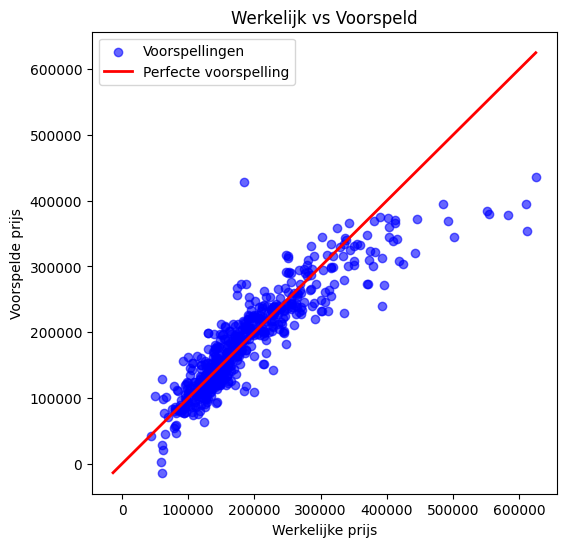

In [16]:
# Importeert matplotlib om grafieken te kunnen maken
import matplotlib.pyplot as plt

# Importeert numpy voor wiskundige berekeningen (zoals min en max bepalen)
import numpy as np


# Laat het getrainde model voorspellingen maken op de testdata
voorspellingen = eerste_pipeline.predict(X_test)


# Maakt een nieuwe figuur (grafiek) met breedte 6 en hoogte 6
plt.figure(figsize=(6,6))


# Maakt een scatterplot:
# X-as = werkelijke prijzen (y_test)
# Y-as = voorspelde prijzen (voorspellingen)
# color = blauw
# alpha = 0.6 (iets transparant)
# label = naam voor legenda
plt.scatter(y_test, voorspellingen, 
            color="blue", 
            alpha=0.6, 
            label="Voorspellingen")


# Bepaalt de kleinste waarde tussen echte en voorspelde prijzen
# Dit gebruiken we om de perfecte lijn correct te tekenen
min_val = min(y_test.min(), voorspellingen.min())

# Bepaalt de grootste waarde tussen echte en voorspelde prijzen
max_val = max(y_test.max(), voorspellingen.max())


# Tekent de perfecte voorspelling-lijn (diagonaal)
# Deze loopt van (min, min) naar (max, max)
# Als punten precies op deze lijn liggen → perfecte voorspelling
plt.plot([min_val, max_val], 
         [min_val, max_val], 
         color="red",          # lijnkleur rood
         linewidth=2,          # iets dikkere lijn
         label="Perfecte voorspelling")


# Geeft de X-as een naam
plt.xlabel("Werkelijke prijs")

# Geeft de Y-as een naam
plt.ylabel("Voorspelde prijs")

# Zet een titel boven de grafiek
plt.title("Werkelijk vs Voorspeld")

# Laat de legenda zien (blauw = voorspellingen, rood = perfecte lijn)
plt.legend()

# Toont de grafiek daadwerkelijk op het scherm
plt.show()

In [15]:
# Dit blok laat alleen de belangrijkste scores netjes zien
samenvatting = resultaten_df[["Experiment", "Aantal features", "max_iter", "eta0", "learning_rate", "MAE", "RMSE", "R2"]].copy()
display(samenvatting.round(3))


,Experiment,Aantal features,max_iter,eta0,learning_rate,MAE,RMSE,R2
0,Exp 4: bijna alle features,10,2000,0.005,adaptive,21603.155,35857.674,0.840
1,Exp 5: bijna alle features + andere epochs/lr,10,3000,0.003,adaptive,21618.715,35875.812,0.839
2,Exp 3: nog meer features,7,2000,0.005,adaptive,22113.765,36291.977,0.836
3,Exp 2: meer features,5,2000,0.005,adaptive,23340.627,37380.964,0.826
4,"Exp 1: zelfde features, andere hyperparameters",3,2000,0.005,adaptive,24938.996,39176.268,0.809
5,Initiële run,3,1000,0.010,invscaling,25603.894,39776.660,0.803


In [16]:
# Dit blok pakt het beste experiment op basis van de laagste RMSE
beste_model = resultaten_df.iloc[0]
display(beste_model)


Experiment                                Exp 4: bijna alle features
Features           Garage, Overall Qual, Gr Liv Area, Total Bsmt ...
Aantal features                                                   10
max_iter                                                        2000
eta0                                                           0.005
learning_rate                                               adaptive
alpha                                                         0.0001
penalty                                                           l2
MAE                                                     21603.154972
MSE                                                 1285772801.26437
RMSE                                                    35857.674231
R2                                                           0.83963
Name: 0, dtype: object

## Conclusie
Door systematisch te experimenteren met features, learning rate, epochs en regularisatie is het model duidelijk verbeterd ten opzichte van de initiële run.

### De grootste verbetering kwam door:

Het toevoegen van meerdere relevante features
Het gebruiken van een adaptive learning rate
Voldoende epochs (2000)
Het beste model was:

### Exp 4: bijna alle features

Met:

1. max_iter = 2000
2. eta0 = 0.005
3. learning_rate = "adaptive"
4. Dit model behaalde:

 - **De laagste RMSE**
 - **De laagste MAE**
 - **De hoogste R²**

### Conclusie: het uitbreiden van de feature-set had de grootste impact op de modelprestatie, gecombineerd met stabiele hyperparameters.

